# EDA Datos AFMP Pruevas Turbinas

In [1]:
# Librerias necesarias

import pandas as pd # Manejo de datos
import numpy  as np # Manejo de numeros
import matplotlib.pyplot as plt # Visualizacion
import seaborn as sns # Visuzalizacion
import ptitprince as pt
import warnings
import os # Para uso de dotenv
from dotenv import load_dotenv # Variables de entorno

warnings.filterwarnings('ignore')

In [2]:
# Carga de los datos

load_dotenv(dotenv_path='/home/asus_juan/Documents/GitHub/Despliegue-modelo-ANN-Turbinas-Hidraulicas/.env') # Cambia la ruta de tu .env

# Extraemos la base de datos del .env
Data = os.getenv('DB_PATH')

# Para asi ver cada sheet del Excel
sheet_pedida = input('Ingresa el Sheet a analizar: ')

# Cargamos el dataset
try:
    # Creamos el dataframe 
    if Data and sheet_pedida is not None:
        df = pd.read_excel(Data, sheet_name=sheet_pedida)
    else:
        print('No existe el path')
except Exception as e:
    print(f'No existe la Sheet debes escribir el formato completo')

In [3]:
df.head(5)

,EXPERIMENTO_ID,Torque [Nm],RPM,Power [kW],Frecuencia,Caudal [lt/s ],Presion (PsiD),Presion (PsiG)
0,EXP_1,0.045234,744,3.524242,30_Hz,8.92584,2.374606,2.266944
1,EXP_1,0.045234,737,3.491084,30_Hz,8.93557,2.365569,2.255212
2,EXP_1,0.210670,730,16.104774,30_Hz,8.94530,2.356532,2.243480
3,EXP_1,0.210670,724,15.972406,30_Hz,8.95364,2.348786,2.233424
4,EXP_1,0.309245,719,23.284139,30_Hz,8.96059,2.342331,2.225044


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1785 entries, 0 to 1784
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   EXPERIMENTO_ID  1785 non-null   str    
 1   Torque [Nm]     1785 non-null   float64
 2   RPM             1785 non-null   int64  
 3   Power [kW]      1785 non-null   float64
 4   Frecuencia      1785 non-null   str    
 5   Caudal [lt/s ]  1785 non-null   float64
 6   Presion (PsiD)  1785 non-null   float64
 7   Presion (PsiG)  1785 non-null   float64
dtypes: float64(5), int64(1), str(2)
memory usage: 111.7 KB


In [5]:
df['Frecuencia'] = df['Frecuencia'].astype(str)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Torque [Nm],1785.0,1.784880,1.016626,0.017625,0.910092,2.058445,2.714777,3.613794
RPM,1785.0,416.880672,246.077989,1.000000,194.000000,417.000000,624.000000,814.000000
Power [kW],1785.0,52.554468,30.849154,0.285442,26.455414,57.228369,81.197299,113.139855
Caudal [lt/s ],1785.0,9.380536,0.342048,8.828540,9.092640,9.380370,9.690340,9.958610
Presion (PsiD),1785.0,1.952285,0.317694,1.415371,1.664540,1.952440,2.219683,2.464978
Presion (PsiG),1785.0,1.718692,0.412427,1.021676,1.345144,1.718892,2.065824,2.384264


## Visualización de datos

Aqui realmente se hara algo bastante importante y es entender la forma en la que se relacionan y se distribuyen los datos. Para esto se pueden usar varias herramientas, pero una de las mas comunes es el uso de gráficos y diagramas.

Luego haremos un análisis de correlación para entender como se relacionan las variables entre si, y con la variable objetivo que es la potencia y usando un mapa de calor para visualizar estas relaciones.

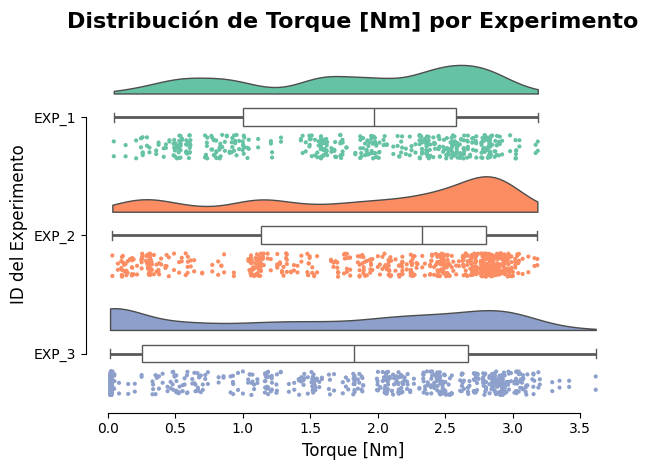

In [7]:
# Creamos una figura con buen tamaño
plt.Figure(figsize=(10,6))

# Generamos el Raincloud Plot
pt.RainCloud(
    x='EXPERIMENTO_ID', # La variable para agrupar 
    y='Torque [Nm]',    # La variable a analizar
    data=df,            # Dataframe de los datos
    palette='Set2',     # Paleta de colores 
    bw=0.2,             # Suavizado de la "nube" (densidad)
    width_viol=0.6,     # Grosor de la nube
    width_box=0.15,     # Grosor del boxplot
    orient='h',         # 'h' para horizontal - 'v' para vertical
    move=0.25            # Separación física entre la lluvia y la nube
)

# Formato y diseño
plt.title('Distribución de Torque [Nm] por Experimento', fontsize=16, fontweight='bold')
plt.xlabel('Torque [Nm]', fontsize=12)
plt.ylabel('ID del Experimento', fontsize=12)

# Ocultar los bordes superior y derecho para que se vea más limpio
sns.despine(trim=True)
plt.tight_layout()

# Mostrar 
plt.show()

1. El hallazgo más importante de este gráfico es que ninguno de los tres experimentos sigue una distribución normal. Todos presentan un comportamiento multimodal, es decir, tienen dos o mas "picos" o masas principales de datos. En términos físicos, esto nos indica que la turbina no operó de forma constante, sino que estuvo alternando entre dos estados o regímenes de trabajo muy distintos:

* Un estado de "Baja carga / Vacío" (valores cercanos a 0 - 1 Nm).
* Un estado de "Alta carga / Trabajo" (valores entre 2.5 y 3.0 Nm).

2. Análisis por Experimento

- EXP_1 (Verde): 

* Distribución: Vemos dos "barrigas" en la nube. Una fuerte alrededor de 0.8 Nm y otra cerca de 2.6 Nm.
* Caja (Boxplot): Su mediana (la línea central de la caja) está cerca de 2.0 Nm. La dispersión de los puntos (la lluvia) muestra que la máquina pasó tiempos similares en ambos regímenes.

- EXP_2 (Naranja): 

* Distribución: La masa principal de datos (la parte más ancha de la nube) está concentrada fuertemente en la parte superior, entre 2.5 y 3.0 Nm. El pico inferior es mucho más pequeño.
* Caja: Tiene la mediana más alta de los tres experimentos (aprox. 2.3 Nm).

- EXP_3 (Azul): El de los extremos.

* Distribución: Es el caso más polarizado. Observa cómo la nube tiene una gran masa justo en 0.0 Nm y otra gran masa arriba de 2.5 Nm, con un "cuello" muy delgado en el medio.
* Caja: Su caja es la más alargada (mayor rango intercuartílico), y su mediana baja drásticamente (cerca de 1.8 Nm) porque hay muchísimos datos arrastrándola hacia abajo.
* Nota: En esta prueba, la turbina tuvo muchísimos momentos de torque nulo (probablemente se haya empezado a tomar datos desde que estaba parado) y momentos de carga alta, con transiciones muy rápidas entre ambos (casi no hay puntos en el medio de la lluvia).

3. Impacto para el Modelo de Machine Learning (ANN - MLP)
Dada la forma de distribucion del Torque no es normal los métodos tradicionales de escalado de datos (como el StandardScaler que asume datos normales) podrían no ser la mejor opción. El modelo podria beneficiarse más de usar MinMaxScaler o incluso de separar el entrenamiento por regímenes operativos en caso de que las demás variables se comportan igual.

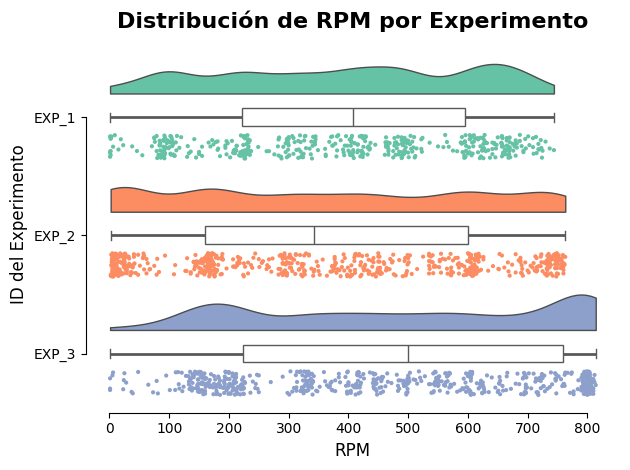

In [8]:
# Creamos una figura con buen tamaño
plt.Figure(figsize=(10,6))

# Generamos el Raincloud Plot
pt.RainCloud(
    x='EXPERIMENTO_ID', # La variable para agrupar 
    y='RPM ',    # La variable a analizar
    data=df,            # Dataframe de los datos
    palette='Set2',     # Paleta de colores 
    bw=0.2,             # Suavizado de la "nube" (densidad)
    width_viol=0.6,     # Grosor de la nube
    width_box=0.15,     # Grosor del boxplot
    orient='h',         # 'h' para horizontal - 'v' para vertical
    move=0.25            # Separación física entre la lluvia y la nube
)

# Formato y diseño
plt.title('Distribución de RPM por Experimento', fontsize=16, fontweight='bold')
plt.xlabel('RPM', fontsize=12)
plt.ylabel('ID del Experimento', fontsize=12)

# Ocultar los bordes superior y derecho para que se vea más limpio
sns.despine(trim=True)
plt.tight_layout()

# Mostrar 
plt.show()

1. A diferencia del Torque las RPM muestran dos estrategias de prueba experimentales completamente distintas. Los Experimentos 1 y 2 tienen un comportamiento casi idéntico entre sí, mientras que el Experimento 3 rompe el patrón por completo.

2. Análisis por Experimento

- EXP_1 (Verde) y EXP_2 (Naranja): 

* Distribución: Las "nubes" de ambos son largas, planas y onduladas, sin un pico dominante. La lluvia de puntos debajo muestra que hay datos a 100, 300, 500 y 700 RPM en proporciones casi iguales.
* Caja: Son cajas muy anchas. Sus medianas están centradas (alrededor de 400 RPM para el EXP_1 y 350 RPM para el EXP_2), lo que refleja un balance perfecto.
* Conclusión Física: Estas pruebas parecen ensayos escalonados o "barridos". Durante la operacion la turbina la hizo acelerar progresivamente a través de todo su espectro operativo para mapear su comportamiento en cada velocidad sin quedarse mucho tiempo en ninguna.

- EXP_3 (Azul):

* Distribución: Aquí la nube cambia drásticamente. Presenta un pico masivo en el extremo derecho (por encima de las 800 RPM) y una segunda agrupación, más dispersa, entre 150 y 250 RPM.
* Caja: Su mediana salta hasta las 500 RPM y el tercer cuartil (el borde derecho de la caja) está casi pegado al límite de las 800 RPM.
* Conclusión Física: Esta prueba simuló condiciones extremas o de alta demanda. La máquina operó a su máxima velocidad durante un periodo de tiempo muy prolongado, intercalado con caídas de velocidad a la zona de 200 RPM, casi sin detenerse en velocidades intermedias.

3. Impacto para la Red Neuronal (ANN - MLP)
Desde el punto de vista del Machine Learning para predecir la potencia de las aspas, este gráfico revela un escenario ideal, pero con una pequeña trampa que se debe manejar de manera correcta en el feature engineering:
* La parte buena: Al tener los experimentos 1 y 2 con una distribución uniforme, La red neuronal tendrá suficientes ejemplos matemáticos para aprender a predecir el comportamiento en todo el rango de velocidades. No habrá "puntos ciegos" en la curva de aprendizaje.
* La trampa: Si divides tus datos en conjuntos de entrenamiento y prueba de forma aleatoria, el exceso de datos a 800 RPM provenientes del Experimento 3 podría sesgar al modelo, haciéndole creer que la turbina casi siempre opera a alta velocidad. Es vital aplicar un muestreo estratificado (stratified sampling) asegurando que la red vea proporciones iguales de los tres experimentos durante el entrenamiento.

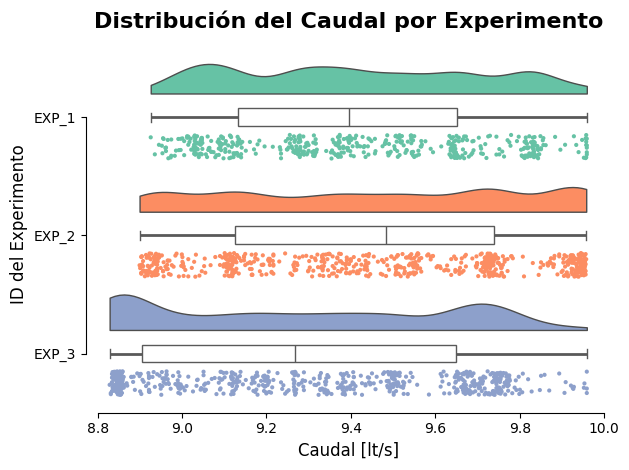

In [9]:
# Creamos una figura con buen tamaño
plt.Figure(figsize=(10,6))

# Generamos el Raincloud Plot
pt.RainCloud(
    x='EXPERIMENTO_ID', # La variable para agrupar 
    y='Caudal [lt/s ]',    # La variable a analizar
    data=df,            # Dataframe de los datos
    palette='Set2',     # Paleta de colores 
    bw=0.2,             # Suavizado de la "nube" (densidad)
    width_viol=0.6,     # Grosor de la nube
    width_box=0.15,     # Grosor del boxplot
    orient='h',         # 'h' para horizontal - 'v' para vertical
    move=0.25            # Separación física entre la lluvia y la nube
)

# Formato y diseño
plt.title('Distribución del Caudal por Experimento', fontsize=16, fontweight='bold')
plt.xlabel('Caudal [lt/s]', fontsize=12)
plt.ylabel('ID del Experimento', fontsize=12)

# Ocultar los bordes superior y derecho para que se vea más limpio
sns.despine(trim=True)
plt.tight_layout()

# Mostrar 
plt.show()

1. El gráfico de nube de lluvia (Raincloud plot) correspondiente al Caudal revela cómo se comportó el flujo de agua a través de la turbina durante las tres pruebas. Aunque el rango operativo general es relativamente estrecho (transitando únicamente entre los 8.8 y 10.0 lt/s), la forma en que se distribuyen los datos varía drásticamente según el experimento, confirmando la relación física del sistema hidrodinámico.

2. Experimentos 1 y 2: Flujo distribuido y uniforme

* Distribucion: Tanto el EXP_1 (verde) como el EXP_2 (naranja) presentan distribuciones anchas, planas y con múltiples ondulaciones menores (platicúrticas). La "lluvia" de puntos muestra una densidad equitativa a lo largo de todo el eje.
* Caja: Sus valores centrales son los más altos de la muestra, situándose alrededor de 9.4 lt/s y 9.5 lt/s, respectivamente.
* Interpretación: Estas pruebas representan ensayos de "barrido" escalonado. El sistema permitió transiciones suaves y equitativas a través de todos los niveles de flujo posibles, sin estancarse en un caudal en particular.

3. Experimento 3: Restricción extrema (Sesgo a la baja)

* Distribucion: El EXP_3 (azul) rompe por completo el patrón de uniformidad. Muestra una clara distribución bimodal, pero con una acumulación masiva de datos en el extremo izquierdo del gráfico (entre 8.8 y 9.0 lt/s).
* Caja: Su caja es la más amplia, pero su mediana es empujada drásticamente hacia abajo (aprox. 9.25 lt/s) debido a la gran cantidad de registros de bajo caudal.
* Interpretación: La turbina pasó la mayor parte de esta prueba operando con el flujo de agua severamente restringido (caudal mínimo).

4. Conclusión Física y Correlación con RPM
Este gráfico es la pieza del rompecabezas que confirma la física de la turbina. Al cruzar esta información con la distribución de las RPM, se corrobora una relación inversa: la concentración masiva de bajo caudal en el EXP_3 (8.8 lt/s) corresponde exactamente a los momentos de "prueba de estrés" donde la turbina giró a su máxima velocidad (más de 800 RPM). A mayor velocidad de giro de las aspas, mayor es la resistencia hidrodinámica que se opone al paso del agua, reduciendo el caudal total del sistema.

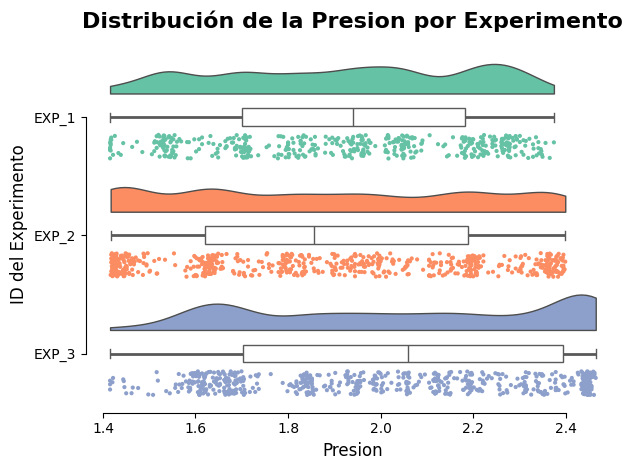

In [10]:
# Creamos una figura con buen tamaño
plt.Figure(figsize=(10,6))

# Generamos el Raincloud Plot
pt.RainCloud(
    x='EXPERIMENTO_ID', # La variable para agrupar 
    y='Presion (PsiD)',    # La variable a analizar
    data=df,            # Dataframe de los datos
    palette='Set2',     # Paleta de colores 
    bw=0.2,             # Suavizado de la "nube" (densidad)
    width_viol=0.6,     # Grosor de la nube
    width_box=0.15,     # Grosor del boxplot
    orient='h',         # 'h' para horizontal - 'v' para vertical
    move=0.25            # Separación física entre la lluvia y la nube
)

# Formato y diseño
plt.title('Distribución de la Presion por Experimento', fontsize=16, fontweight='bold')
plt.xlabel('Presion', fontsize=12)
plt.ylabel('ID del Experimento', fontsize=12)

# Ocultar los bordes superior y derecho para que se vea más limpio
sns.despine(trim=True)
plt.tight_layout()

# Mostrar 
plt.show()

1. El gráfico de nube de lluvia (Raincloud plot) para la variable de Presión consolida los hallazgos observados en las variables físicas anteriores (RPM y Caudal), mostrando cómo responde el sistema ante diferentes regímenes de exigencia.

2. Experimentos 1 y 2: Presión distribuida y transiciones suaves

* Distribucion: Los experimentos 1 (verde) y 2 (naranja) muestran distribuciones notablemente uniformes y planas a lo largo de casi todo el espectro de presión (desde 1.4 hasta 2.4). Las nubes no presentan picos dominantes, sino fluctuaciones suaves.
* Caja: Se ubican en el centro del rango operativo, alrededor de 1.95 y 1.85 respectivamente, con cajas (rangos intercuartílicos) muy anchas.
* Interpretación: Al igual que con las RPM y el Caudal, esto confirma que las pruebas 1 y 2 fueron "barridos" operativos continuos. La turbina experimentó todos los niveles de presión de forma equitativa al transitar por distintas velocidades y flujos de manera progresiva.

2. Experimento 3: Acumulación de Alta Presión

* Distribucion: El EXP_3 (azul) cambia radicalmente la geometría de la distribución. Presenta una concentración masiva de datos en el extremo derecho del gráfico (alta presión, cerca de 2.4 - 2.5), formando un pico muy pronunciado en la "nube" y una densa aglomeración en la "lluvia" de puntos.
* Caja: A diferencia de los otros experimentos, la mediana de la caja se desplaza fuertemente hacia la derecha (aprox. 2.05), arrastrada por la gran cantidad de lecturas de alta presión.
* Interpretación: Durante esta prueba, el sistema estuvo sometido a condiciones que forzaron la presión a mantenerse en sus niveles máximos durante periodos prolongados, intercalados con caídas abruptas (reflejadas en la leve barriga izquierda de la nube cerca de 1.7).

3. Conclusión Física Integral (Torque, RPM, Caudal y Presión)
* Esta gráfica es la pieza final que valida la coherencia física de los datos recopilados. En el análisis previo del EXP_3, observamos que la turbina operó a máxima velocidad (RPM extremas) pero con el flujo de agua severamente restringido (Caudal mínimo). Físicamente, obligar a una turbina a girar a alta velocidad mientras se estrangula el flujo genera un estancamiento o acumulación de presión en el sistema. El pico masivo en 2.5 de esta gráfica confirma matemáticamente esa realidad física: el "estrés" de la máquina se traduce directamente en alta presión.

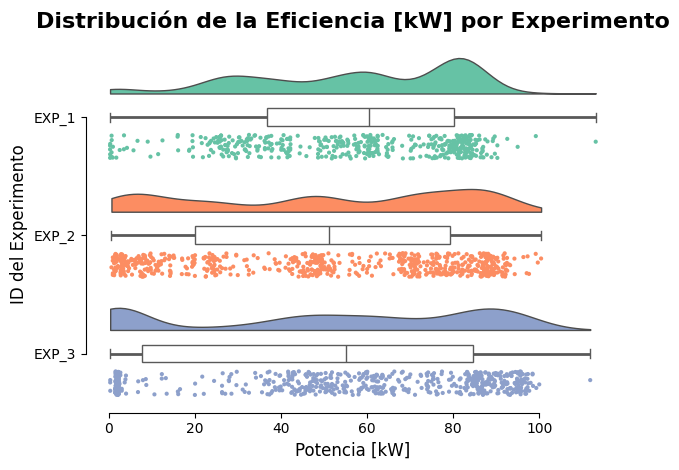

In [11]:
# Creamos una figura con buen tamaño
plt.Figure(figsize=(10,6))

# Generamos el Raincloud Plot
pt.RainCloud(
    x='EXPERIMENTO_ID', # La variable para agrupar 
    y='Power [kW]',    # La variable a analizar
    data=df,            # Dataframe de los datos
    palette='Set2',     # Paleta de colores 
    bw=0.2,             # Suavizado de la "nube" (densidad)
    width_viol=0.6,     # Grosor de la nube
    width_box=0.15,     # Grosor del boxplot
    orient='h',         # 'h' para horizontal - 'v' para vertical
    move=0.25            # Separación física entre la lluvia y la nube
)

# Formato y diseño
plt.title('Distribución de la Eficiencia [kW] por Experimento', fontsize=16, fontweight='bold')
plt.xlabel('Potencia [kW]', fontsize=12)
plt.ylabel('ID del Experimento', fontsize=12)

# Ocultar los bordes superior y derecho para que se vea más limpio
sns.despine(trim=True)
plt.tight_layout()

# Mostrar 
plt.show()

El gráfico de nube de lluvia (Raincloud plot) correspondiente a la Potencia (Power [kW]) representa la salida de energía final de la turbina. Al ser nuestra variable objetivo, su distribución nos permite validar matemáticamente las decisiones operativas y los esfuerzos físicos observados en los gráficos anteriores (Torque, RPM, Caudal y Presión).

1. Experimento 1 (Verde): Sesgo hacia la alta generación

* Distribucion: Aunque es producto de un "barrido" operativo, la masa de datos no es plana. La "nube" muestra una fuerte concentración de valores en la mitad superior del espectro (entre 60 y 90 kW), con el pico más denso cerca de los 85 kW.Medianas: Su caja tiene la mediana más alta de los tres experimentos (aprox. 60 kW).
* Interpretación Física: Durante el barrido de velocidades y flujos de esta prueba, el sistema pasó una mayor proporción de tiempo operando en zonas de alta eficiencia de la curva de la turbina, maximizando la extracción de energía del fluido.

2. Experimento 2 (Naranja): Mapeo Uniforme y Continuo

* Distribucion: A diferencia del EXP_1, el EXP_2 exhibe una distribución notablemente plana y extensa (platicúrtica). La lluvia de puntos demuestra que la turbina generó todos los niveles posibles de potencia, desde casi 0 hasta 100 kW, de manera equitativa.
* Caja: Su caja es amplia y perfectamente centrada alrededor de los 50 kW.
* Interpretación Física: Esta es la firma visual de una prueba de caracterización perfecta. La máquina recorrió su curva de potencia de extremo a extremo a un ritmo constante, sin detenerse en ninguna zona de operación en particular.

3. Experimento 3 (Azul): Estados Extremos y Caída a Cero

* Distribucion: El EXP_3 confirma su naturaleza de "prueba de estrés". Presenta una clara bimodalidad con un detalle crítico: una acumulación masiva de puntos exactamente en el límite de 0 kW, seguida de un valle, y luego una distribución amplia en las zonas medias-altas.
* Caja: Su mediana se sitúa cerca de los 55 kW, pero la caja se estira hacia abajo dramáticamente (el primer cuartil llega casi a los 10 kW) arrastrada por los ceros.
* Interpretación Física y Correlación: Este pico en 0 kW se correlaciona directamente con el comportamiento bimodal que vimos en el gráfico de Torque. Dado que la Potencia Mecánica es el producto del Torque por la Velocidad Angular ($P = \tau \cdot \omega$), los momentos en los que el torque cayó a 0 Nm (turbina girando libre sin resistencia o completamente estancada) resultaron invariablemente en 0 kW de potencia generada, a pesar de que las RPM o la Presión estuvieran al máximo.

Text(0, 0.5, 'Power (Watts)')

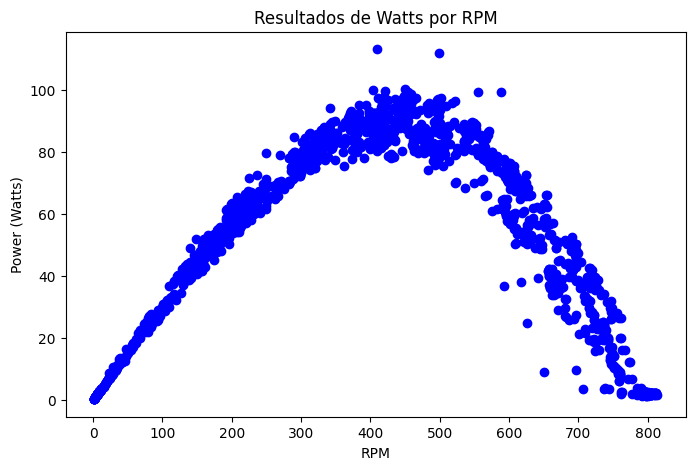

In [12]:
# Esta grafica muestra la evolucion del Power en relacion de las RPM
# Cabe resaltar que aqui aun no se aplica feature_engeneering

plt.figure(figsize=(8,5))
plt.plot(df['RPM '], df['Power [kW]'], marker='o', linestyle='', color='b')
plt.title('Resultados de Watts por RPM')
plt.xlabel('RPM')
plt.ylabel('Power (Watts)')

## Feature Engineering 
 
Como se evidencia en la grafica anterior hay muchos valores atipicos que pueden molestar a nuestro modelo mas adelante y es importante tratarlos de alguna manera, ya sea eliminandolos o transformandolos. En este caso se opta por eliminarlos, ya que no se tiene una gran cantidad de datos y se prefiere tener datos mas limpios para entrenar el modelo.

In [13]:
np.info(np.polyfit)

Least squares polynomial fit.

.. note::
   This forms part of the old polynomial API. Since version 1.4, the
   new polynomial API defined in `numpy.polynomial` is preferred.
   A summary of the differences can be found in the
   :doc:`transition guide </reference/routines.polynomials>`.

Fit a polynomial ``p[0] * x**deg + ... + p[deg]`` of degree `deg`
to points `(x, y)`. Returns a vector of coefficients `p` that minimises
the squared error in the order `deg`, `deg-1`, ... `0`.

The `Polynomial.fit <numpy.polynomial.polynomial.Polynomial.fit>` class
method is recommended for new code as it is more stable numerically. See
the documentation of the method for more information.

Parameters
----------
x : array_like, shape (M,)
    x-coordinates of the M sample points ``(x[i], y[i])``.
y : array_like, shape (M,) or (M, K)
    y-coordinates of the sample points. Several data sets of sample
    points sharing the same x-coordinates can be fitted at once by
    passing in a 2D-array that con

In [14]:
np.info(np.poly1d)

 poly1d(c_or_r, r=False, variable=None)

A one-dimensional polynomial class.

.. note::
   This forms part of the old polynomial API. Since version 1.4, the
   new polynomial API defined in `numpy.polynomial` is preferred.
   A summary of the differences can be found in the
   :doc:`transition guide </reference/routines.polynomials>`.

A convenience class, used to encapsulate "natural" operations on
polynomials so that said operations may take on their customary
form in code (see Examples).

Parameters
----------
c_or_r : array_like
    The polynomial's coefficients, in decreasing powers, or if
    the value of the second parameter is True, the polynomial's
    roots (values where the polynomial evaluates to 0).  For example,
    ``poly1d([1, 2, 3])`` returns an object that represents
    :math:`x^2 + 2x + 3`, whereas ``poly1d([1, 2, 3], True)`` returns
    one that represents :math:`(x-1)(x-2)(x-3) = x^3 - 6x^2 + 11x -6`.
r : bool, optional
    If True, `c_or_r` specifies the polynomi

In [15]:
# Mediante una reduccion polinimica de outliers hacemos que los valores no excedan el percentil 92

z = np.polyfit(df['RPM '], df['Power [kW]'], 2) # Devuelve un array 
p = np.poly1d(z) # Devuelve el array de una sola clase

df['Residuo'] = abs(df['Power [kW]'] - p(df['RPM '])) # Calculamos el residuo que queda entre el Power y las RPM


umbral = df['Residuo'].quantile(0.92) # Para no exceder este umbral
df = df[df['Residuo'] < umbral] # Solamente colocamos los datos que esten debajo del umbral

Text(0, 0.5, 'Power (Watts)')

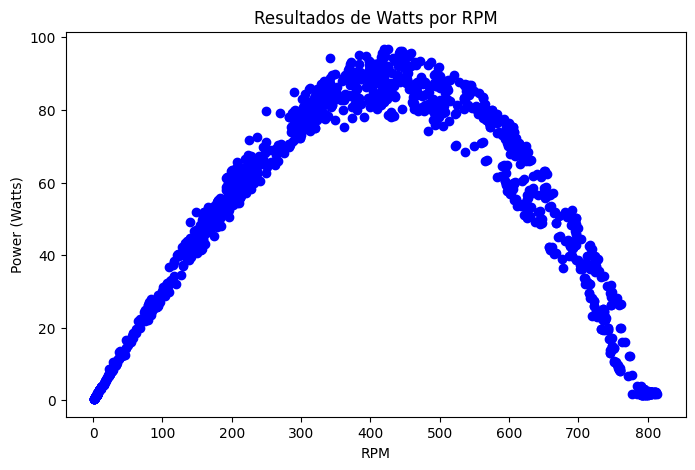

In [16]:
# Grafica ya sin outliers

plt.figure(figsize=(8,5))
plt.plot(df['RPM '], df['Power [kW]'], marker='o', linestyle='', color='b')
plt.title('Resultados de Watts por RPM')
plt.xlabel('RPM')
plt.ylabel('Power (Watts)')

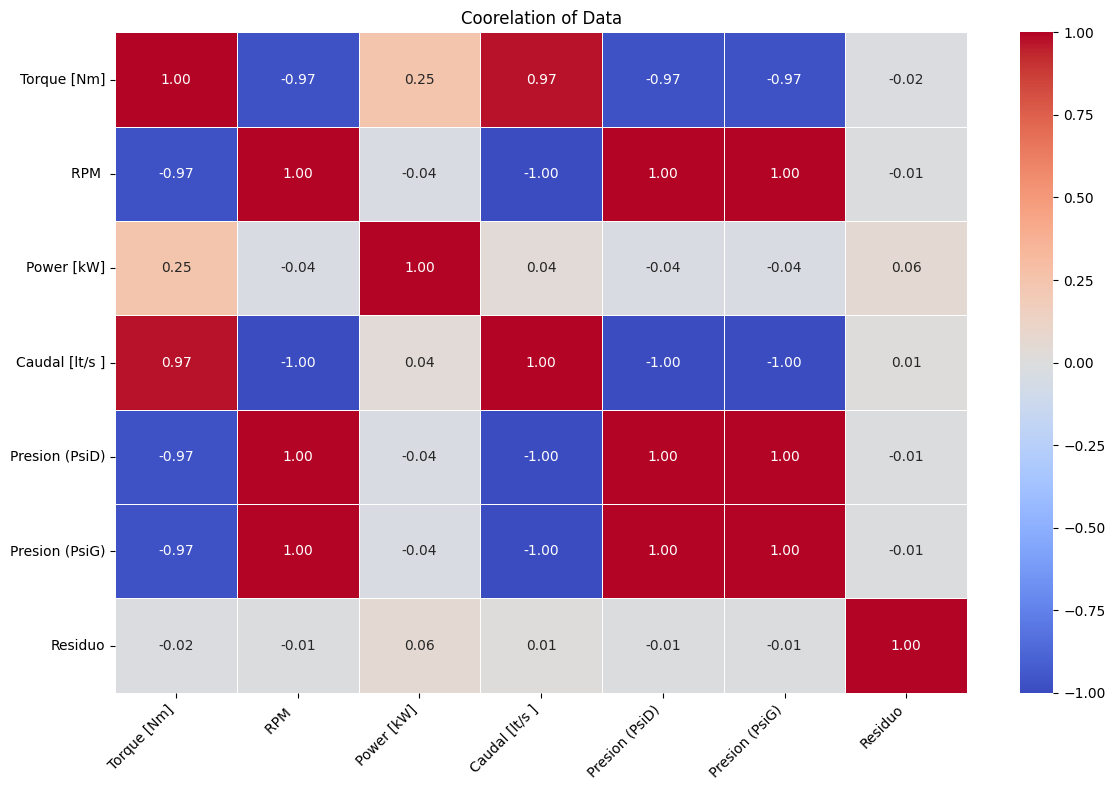

In [17]:
df_Numeric = df.select_dtypes('number')
coor_matrix = df_Numeric.corr() 

plt.figure(figsize=(12,8))
sns.heatmap(
    coor_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title('Coorelation of Data')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()